# SABR interpolation on cleaned historical data

Same **dataset** as in `docs/sabr_interpolation.md` (processed parquet from `data_pipeline.py` → `clean_data` → `processed.parquet`). Pick any **evaluation** grids `k_grid` and `tau_grid` for the dense surface; they do not need to match a kernel smoother.

Interpolation follows the repo SABR path: **per-expiry** `(α, ρ, ν)` with fixed `β`, then **`implied_vol_surface_from_calibrated_slices`** (Hagan lognormal `sabr_lognormal_iv` on each grid point), wired for historic quotes by **`build_historical_sabr_surface`** (`filter_day_for_surface`, expiry grouping, `m = exp(k)` for moneyness).

Run with `pip install -e .` from the repo root.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd

from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    load_cleaned_data,
    plot_smile,
    plot_surface_3d,
)
from implied_volatility_diffusion.data.historical_sabr_interpolation import (
    build_historical_sabr_surface,
)

## Load cleaned data

Default path matches `config/data_pipeline_config.yaml` (`processed_output_path`).

In [6]:
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

processed_data_path = repo_root / "data" / "processed" / "processed.parquet"
df = load_cleaned_data(processed_data_path)

sample_date = pd.Timestamp("2021-06-17")
day = df[df["quote_date"] == sample_date].copy()
print("cleaned dataset:", processed_data_path)
print("sample_date:", sample_date, "rows (this day):", len(day))

r, q, beta = 0.03, 0.0, 0.5

cleaned dataset: /Users/sbonelomdluli/Desktop/implied-volatility-diffusion/data/processed/processed.parquet
sample_date: 2021-06-17 00:00:00 rows (this day): 14699


## SABR dense surface (choose your own evaluation grids)

Below: log-moneyness `k` and maturity `tau` axes for **model evaluation only** (same spirit as `docs/sabr_interpolation.md` § full surface / historic example; change resolution and ranges as you like).

In [7]:
k_grid = np.linspace(-0.2, 0.2, 41)
tau_grid = np.linspace(0.05, 1.0, 24)
KGRID, TAUGRID = np.meshgrid(k_grid, tau_grid, indexing="ij")

sabr_out = build_historical_sabr_surface(day, k_grid, tau_grid, r=r, q=q, beta=beta)
Z_sabr = sabr_out.surface

print("SABR — filtered rows:", len(sabr_out.day_sub), "surface shape:", Z_sabr.shape)
print("finite:", np.isfinite(Z_sabr).sum(), "/", Z_sabr.size, "spot:", sabr_out.spot)
print("(alpha, rho, nu) per expiry:\n", sabr_out.calibrated_params)

SABR — filtered rows: 12812 surface shape: (41, 24)
finite: 984 / 984 spot: 4221.88
(alpha, rho, nu) per expiry:
 [[ 4.00834363 -0.44967813 11.76474206]
 [ 5.13150231 -0.52190946  9.32104396]
 [ 6.36007852 -0.51876132  7.30731327]
 [ 6.24591613 -0.53914632  6.08880287]
 [ 6.50952632 -0.27847516  5.6390923 ]
 [ 5.41553489 -0.16944055  6.11734497]
 [ 6.20690047 -0.51073057  5.19241084]
 [ 6.3138474  -0.5702617   5.07092851]
 [ 6.81720154 -0.6202282   4.6088868 ]
 [ 6.85712558 -0.64190854  4.31156482]
 [ 7.07525748 -0.64523282  4.12248163]
 [ 6.51300405 -0.70484424  4.51508737]
 [ 7.10854168 -0.70529683  4.03256914]
 [ 7.30838071 -0.69451884  3.72187953]
 [ 7.40807166 -0.68822041  3.49925745]
 [ 7.88652328 -0.68877081  3.1048449 ]
 [ 8.36597733 -0.67440743  2.41946071]
 [ 8.74050661 -0.6796435   2.2159087 ]
 [ 9.19768081 -0.68721916  1.88046391]
 [ 9.39558201 -0.68680671  1.74549328]
 [ 9.60717029 -0.67199477  1.62913873]
 [ 9.8256791  -0.6916812   1.53212774]
 [ 9.9009529  -0.66121938  1

## Plots

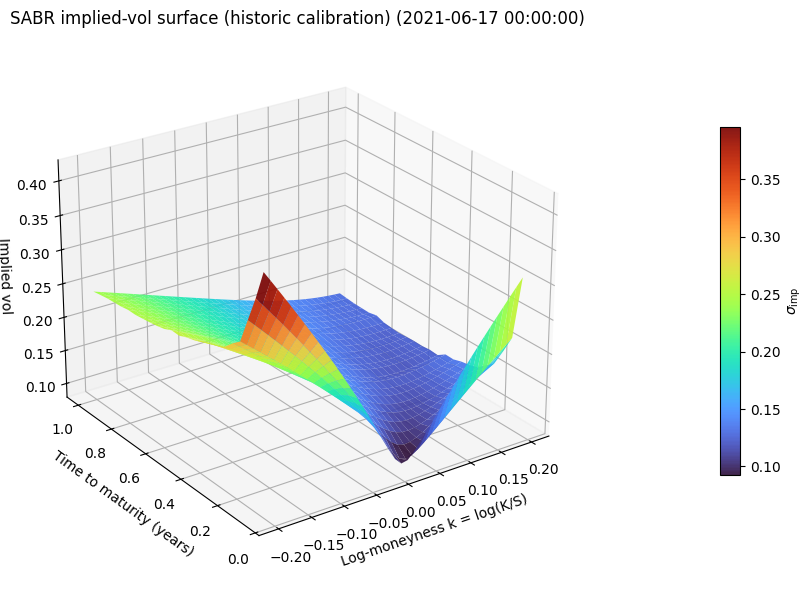

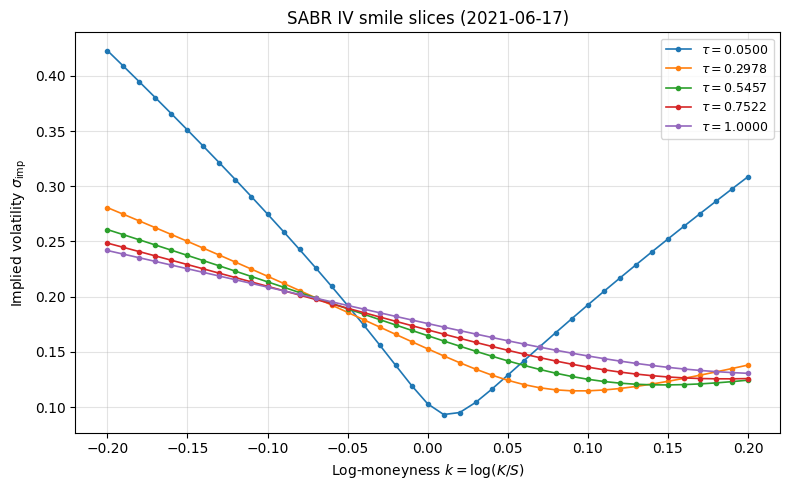

In [8]:
plot_surface_3d(
    KGRID,
    TAUGRID,
    Z_sabr,
    sample_date,
    title="SABR implied-vol surface (historic calibration)",
)

plot_smile(
    k_grid,
    tau_grid,
    Z_sabr,
    sample_date,
    title="SABR IV smile slices",
)